# Gather fire data Brazil

nota: la chieave API deve essere generata associando una email e scade dopo un certo numero di richieste poi deve essere rinnovata.

Non accetta richieste frequenti (qualche minuto almeno di attesa)


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

MAP_KEY = '63fb02bde23144ea120a3123f959bf4c'
SOURCE = 'VIIRS_SNPP_NRT'
DAYS = '5'
BBOX = '-75,-35,-33,6'

# 1. Fetch data from the FIRMS API
print("Fetching fire data...")
url = f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{SOURCE}/{BBOX}/{DAYS}'
fires_df = pd.read_csv(url)

# 2. Convert the FIRMS data to a GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude),
    crs="EPSG:4326"
)



Fetching fire data...


# add coffee production areas



1. Fetching fire data from NASA FIRMS...
2. Fetching Brazil map boundaries...
3. Loading CONAB Coffee Production statistics...
4. Generating side-by-side maps...


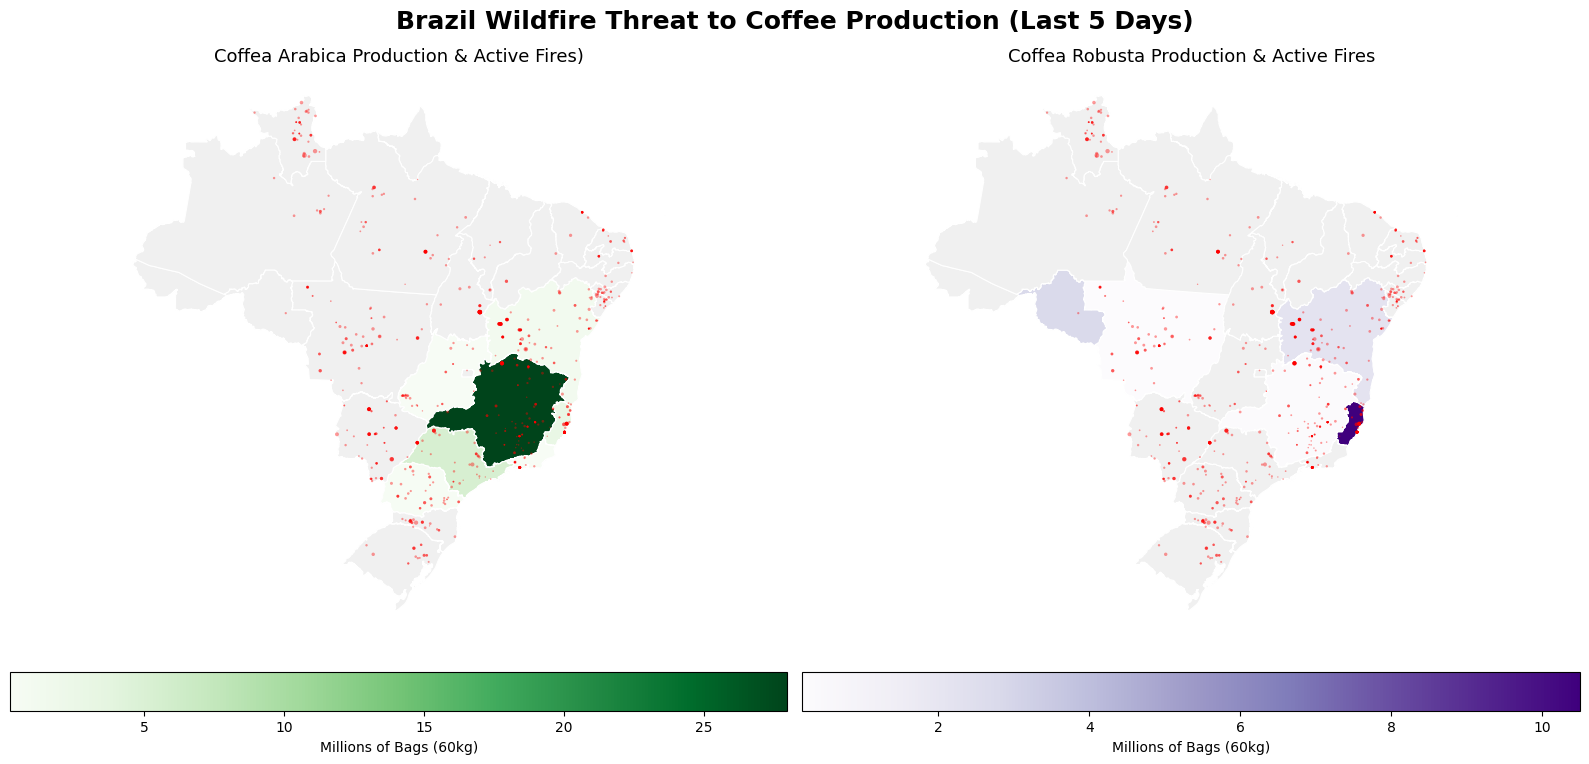

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import requests
import io

MAP_KEY = '63fb02bde23144ea120a3123f959bf4c'  # Make sure your key is active!
SOURCE = 'VIIRS_SNPP_NRT'
DAYS = '5'
BBOX = '-75,-35,-33,6'

# 1. Safely fetch data from the FIRMS API
print("1. Fetching fire data from NASA FIRMS...")
url = f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{SOURCE}/{BBOX}/{DAYS}'
response = requests.get(url)

if response.status_code != 200:
    raise Exception(f"NASA API Error {response.status_code}: {response.text}")

fires_df = pd.read_csv(io.StringIO(response.text))
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude),
    crs="EPSG:4326"
)

# 2. Fetch Brazil state boundaries
print("2. Fetching Brazil map boundaries...")
geojson_url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
brazil_states = gpd.read_file(geojson_url)

# 3. Load 2024 Coffee Production Data
# (Values are in Millions of 60kg bags, based on CONAB 2024 harvest estimates)
print("3. Loading CONAB Coffee Production statistics...")
coffee_data = {
    'sigla': ['MG', 'ES', 'SP', 'BA', 'RO', 'PR', 'RJ', 'GO', 'MT'],
    'Arabica': [28.0, 3.0, 5.4, 1.2, 0.0, 0.5, 0.3, 0.2, 0.0],
    'Robusta': [0.3, 10.5, 0.0, 2.2, 2.8, 0.0, 0.0, 0.0, 0.2]
}
coffee_df = pd.DataFrame(coffee_data)

# Merge the geographic boundaries with the coffee statistics
brazil_map = brazil_states.merge(coffee_df, on='sigla', how='left')

# Replace 0.0 and missing values with NaN so non-producing states show up as neutral grey
brazil_map['Arabica'] = brazil_map['Arabica'].replace(0, np.nan)
brazil_map['Robusta'] = brazil_map['Robusta'].replace(0, np.nan)

# Filter fires to Brazil
fires_in_brazil = gpd.sjoin(fires_gdf, brazil_states, how="inner", predicate="intersects")
marker_sizes = np.sqrt(fires_in_brazil['frp']) * 1.5

# 4. Generate the Visualization
print("4. Generating side-by-side maps...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f'Brazil Wildfire Threat to Coffee Production (Last {DAYS} Days)', fontsize=18, fontweight='bold')

# --- MAP 1: ARABICA ---
ax1.set_title('Coffea Arabica Production & Active Fires)', fontsize=13)
brazil_map.plot(
    column='Arabica', ax=ax1, cmap='Greens',
    edgecolor='white', linewidth=0.8,
    legend=True,
    legend_kwds={'label': "Millions of Bags (60kg)", 'orientation': "horizontal", 'pad': 0.05},
    missing_kwds={'color': '#f0f0f0'} # Colors non-coffee states light grey
)
# Overlay fires in solid red
ax1.scatter(fires_in_brazil.geometry.x, fires_in_brazil.geometry.y, c='red', s=marker_sizes, alpha=0.4, edgecolors='none')
ax1.axis('off')

# --- MAP 2: ROBUSTA (CONILON) ---
ax2.set_title('Coffea Robusta Production & Active Fires', fontsize=13)
brazil_map.plot(
    column='Robusta', ax=ax2, cmap='Purples',
    edgecolor='white', linewidth=0.8,
    legend=True,
    legend_kwds={'label': "Millions of Bags (60kg)", 'orientation': "horizontal", 'pad': 0.05},
    missing_kwds={'color': '#f0f0f0'}
)
# Overlay fires in solid red
ax2.scatter(fires_in_brazil.geometry.x, fires_in_brazil.geometry.y, c='red', s=marker_sizes, alpha=0.4, edgecolors='none')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Posizionamento sulla mappa degli incendi


Fetching Brazil map boundaries...

Top 10 States by Fire Count:
name
Bahia                 139
Espírito Santo        132
Minas Gerais          113
Mato Grosso do Sul     78
Mato Grosso            66
São Paulo              64
Rio de Janeiro         54
Pará                   51
Tocantins              43
Roraima                41
Name: count, dtype: int64

Generating map...


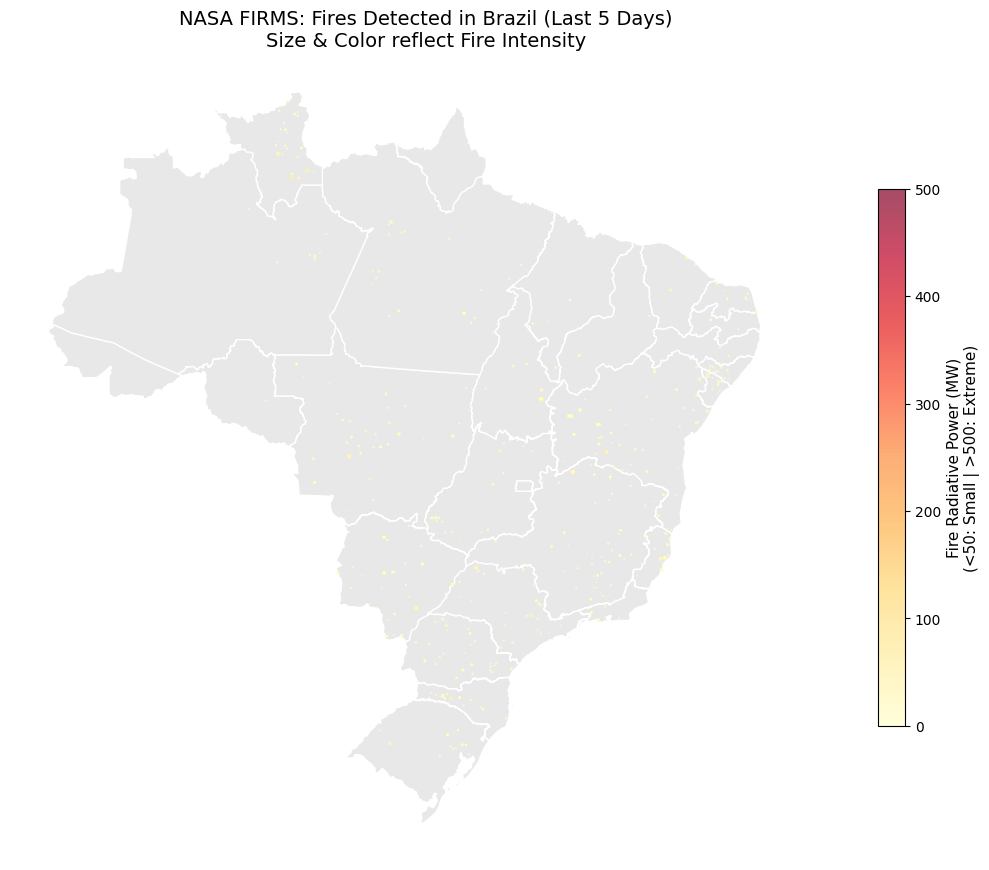

In [3]:
# 3. Load Brazil states map directly from a public GeoJSON URL
# This bypasses the need for a local file and fixes the DataSourceError
print("Fetching Brazil map boundaries...")
geojson_url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
brazil_states = gpd.read_file(geojson_url)

# 4. Perform a spatial join
# This filters out any BBOX fires that are in the ocean or neighboring countries
fires_in_brazil = gpd.sjoin(fires_gdf, brazil_states, how="inner", predicate="intersects")

# 5. Count the number of fires per state (this GeoJSON uses 'name' for the state name)
print("\nTop 10 States by Fire Count:")
state_counts = fires_in_brazil['name'].value_counts()
print(state_counts.head(10))

# 6. Plot the Map
print("\nGenerating map...")
fig, ax = plt.subplots(figsize=(10, 10))

# Draw the base map of Brazil
brazil_states.plot(ax=ax, color='#e8e8e8', edgecolor='white')

# We use the square root for sizing so big fires don't eat the whole map
import numpy as np
marker_sizes = np.sqrt(fires_in_brazil['frp']) * 1.5

# Plot the fires using a colormap ('YlOrRd' = Yellow to Orange to Red)
# We set vmin and vmax to lock the color scale to our 0-500+ MW heuristic
scatter = ax.scatter(
    x=fires_in_brazil.geometry.x,
    y=fires_in_brazil.geometry.y,
    c=fires_in_brazil['frp'],  # Color based on FRP
    s=marker_sizes,            # Size based on FRP
    cmap='YlOrRd',             # Yellow-Orange-Red color scale
    vmin=0, vmax=500,          # Cap the color scale at 500 MW for 'Extreme'
    alpha=0.7,
    edgecolors='none'
)

# Add a colorbar to act as our scale legend
cbar = plt.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Fire Radiative Power (MW)\n(<50: Small | >500: Extreme)', fontsize=11)

# Formatting
plt.title(f'NASA FIRMS: Fires Detected in Brazil (Last {DAYS} Days)\nSize & Color reflect Fire Intensity', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()